# Foundation/Housekeeping

Importing Relevant Libraries/Tools

In [216]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Cleaning

Creating DataFrame and Initial Clean Up

In [217]:
# ensuring excel file is not corrupt

xls = pd.ExcelFile("fixed_excel.xlsx")
print(xls.sheet_names)

['Sheet1']


In [218]:
# creating dataframe
df = pd.read_excel(r"fixed_excel.xlsx") # reads data directly from Excel so the notebook always uses the latest saved version

# standardizing lowercase headers for convenience
df.columns = df.columns.str.lower() # lowercase all headers

# anonomyzing companies
company_dict = {company: f"C{idx:03d}" for idx, company in enumerate(df["company"].unique())} # creating unique id for each company and storing in a dictionary

df["company_id"] = df["company"].map(company_dict) # mapping new ids to company names

df = df.drop(columns=["company"]) # removing original column with real company names

# checking df anonymized dataframe
# df

# Data Cleaning

In [219]:
# checking basic data info: types, total entries, etc...
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   major                       34 non-null     object        
 1   application date            33 non-null     datetime64[ns]
 2   result date                 0 non-null      float64       
 3   job listing posted          3 non-null      object        
 4   role                        34 non-null     object        
 5   job/internship              34 non-null     object        
 6   resume                      34 non-null     object        
 7   custom/standard resume?     34 non-null     object        
 8   transcript                  34 non-null     object        
 9   cover letter                34 non-null     object        
 10  ghosted                     5 non-null      object        
 11  round 1                     3 non-null      object        
 

In [220]:
# ensuring type datetime objects are not altered; result dates will eventually become datetime objects as I hear back from employers
columns_lower = [lower for lower in df.columns if lower not in ["application date", "result date"]] # only capturing columns that are not date columns

# altering all columns except "date" to lowercase strings for ease of use and consistency
df[columns_lower] = df[columns_lower].astype(str).apply(lambda x: x.str.lower())

# replacing "nan" strings with to the value 0; will convert "yes" and "no" to binary eventually
df[columns_lower] = df[columns_lower].replace({"nan":0})

# checking types are consistent with the transformation
df.info()

# checking new dataframe
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   major                       34 non-null     object        
 1   application date            33 non-null     datetime64[ns]
 2   result date                 0 non-null      float64       
 3   job listing posted          34 non-null     object        
 4   role                        34 non-null     object        
 5   job/internship              34 non-null     object        
 6   resume                      34 non-null     object        
 7   custom/standard resume?     34 non-null     object        
 8   transcript                  34 non-null     object        
 9   cover letter                34 non-null     object        
 10  ghosted                     34 non-null     object        
 11  round 1                     34 non-null     object        
 

/var/folders/66/0pgksbln22l1cf4c79r9bnr00000gn/T/ipykernel_59301/2342308958.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[columns_lower] = df[columns_lower].replace({"nan":0})


,major,application date,result date,job listing posted,role,job/internship,resume,custom/standard resume?,transcript,cover letter,...,platform,reached out?,country,attendance,hourly rate,salary,industry,meet qualifications,year,company_id
0,data science,2026-02-04,NaN,0,data management intern,internship,yes,standard,no,yes,...,handshake,0,united states,remote/hybrid/in person,20,0,business,yes,junior,c000
1,igs,2026-04-26,NaN,0,researcher,internship,yes,standard,no,yes,...,handshake,0,united states,remote/hybrid/in person,0,0,non-profit,yes,junior,c001
2,data science,2026-04-26,NaN,0,data analyst intern,internship,yes,standard,no,no,...,employer website,0,united states,remote,$17-$21.50,0,manufacturing,yes,junior,c002
3,data science,2026-04-27,NaN,0,data analyst intern,internship,yes,standard,no,yes,...,employer website,0,united states,remote,$15-$20,0,"journalism, media, and publishing",yes,junior,c003
4,data science,2026-04-27,NaN,0,data analyst intern,internship,yes,standard,no,no,...,employer website,0,united states,remote/hybrid/in person,25,0,transportation and logistics,yes,junior,c004


# Creating Basic Plots

                                      role  total
3                      data analyst intern      8
9                      data science intern      5
2                             data analyst      3
16             software engineering intern      3
14                              researcher      2
10  e-commerce growth and marketing intern      1
15        sales technical analytics intern      1
13                        python developer      1
12                       operations intern      1
11             learning data and analytics      1


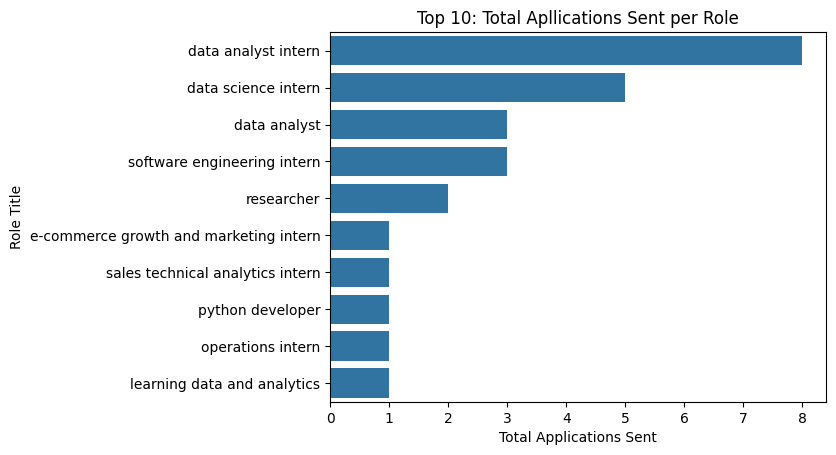

In [221]:
# creating DataFrameGroupBy object to keep count of number of applications per role
grouped_role = df.groupby("role").size().reset_index(name = "total").sort_values(by = "total", ascending = False).head(10) # grouping data based on role title, using size to keep count, reseting index to return Series object produced by size into DataFrame, and sorting values in descending order

# print text running totals
print(grouped_role)

# basic bar plot visualization of counts
sns.barplot(data = grouped_role, x = "total", y = "role")

# adjusting aesthetics: titles
plt.title("Top 10: Total Apllications Sent per Role")
plt.xlabel("Total Applications Sent")
plt.ylabel("Role Title")

plt.show()

In [222]:
# grouping all "data" related roles under one group
import re

# creating regex and will parse through str in "role" column in order to match
regex_data = r".*data.*"

# replacing any data detected roles into umbrella term
df["role"] = df["role"].replace(regex_data, "data role", regex = True)

# checking if ALL data roles have successfully been changed 
df["role"].unique()

array(['data role', 'researcher', 'software engineering intern',
       'sales technical analytics intern',
       'e-commerce growth and marketing intern',
       'ai/machine learning engineering intern', 'operations intern',
       'solar development intern', 'python developer',
       'ai olympiad instructor'], dtype=object)

Same Data but Visualized Through Pie Chart

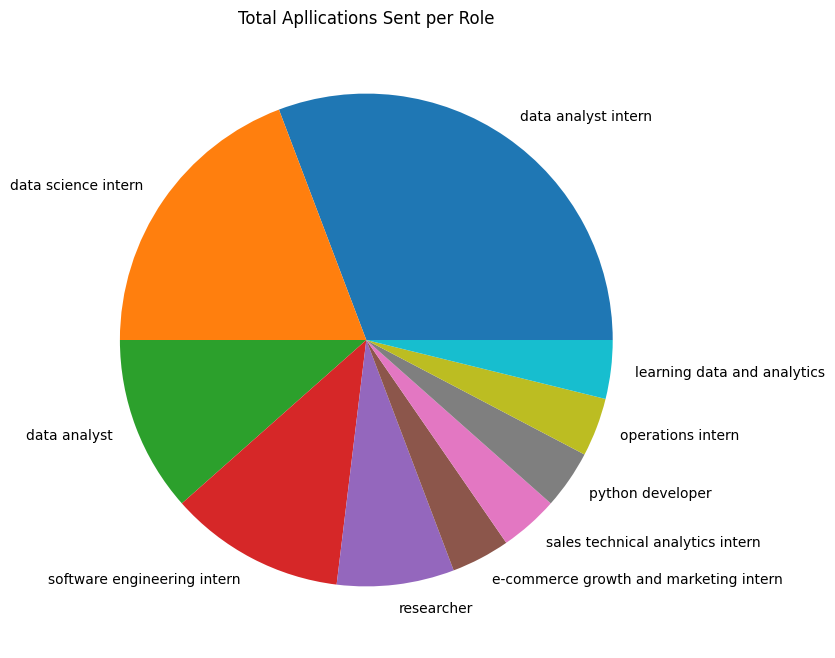

In [223]:
# aesthetic adjustments: size, plot title, etc...
plt.figure(figsize = (8,8))
plt.title("Total Apllications Sent per Role")

# creating pie chart
plt.pie(grouped_role["total"], labels = grouped_role["role"]);

plt.show()

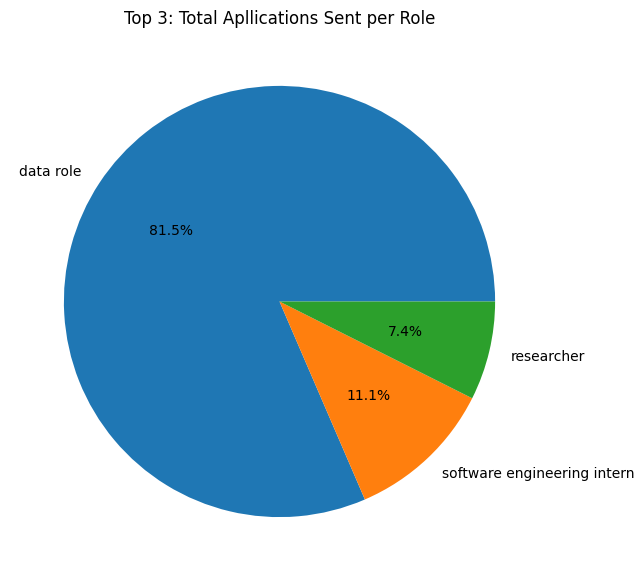

In [237]:
# creating new groupby object with updated "data role" 
data_grouped = df.groupby("role").size().sort_values(ascending = False).reset_index(name = "total").head(3)

# aesthetic adjustments: size, plot title, etc...
plt.figure(figsize = (7,7))
plt.title("Top 3: Total Apllications Sent per Role")

# creating pie chart to reflect changes into umbrelle term "data role"
plt.pie(data_grouped["total"], labels = data_grouped["role"], autopct='%1.1f%%');

# Future Questions
- Is there any relation between accesibility and communication with recruiters in terms of application advancement?
- Do the presence of additional documents (cover letter, transcript, etc) lead to trends in application advancement?
- Does applying as early as possible lead to more desireable outcomes? (Does how long the listing has been open affect outcomes?)